In [1]:
from module import *

# Info

In [2]:
table_info("hourly_calories")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5 non-null      float64
 1   ActivityHour  5 non-null      str    
 2   Calories      5 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


,Id,ActivityHour,Calories
0,1.503960e+09,3/12/2016 12:00:00 AM,48
1,1.503960e+09,3/12/2016 1:00:00 AM,48
2,1.503960e+09,3/12/2016 2:00:00 AM,48
3,1.503960e+09,3/12/2016 3:00:00 AM,48
4,1.503960e+09,3/12/2016 4:00:00 AM,48


In [3]:
table_info("hourly_intensity")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Id                5 non-null      float64
 1   ActivityHour      5 non-null      str    
 2   TotalIntensity    5 non-null      int64  
 3   AverageIntensity  5 non-null      float64
dtypes: float64(2), int64(1), str(1)
memory usage: 292.0 bytes


,Id,ActivityHour,TotalIntensity,AverageIntensity
0,1.503960e+09,3/12/2016 12:00:00 AM,0,0.0
1,1.503960e+09,3/12/2016 1:00:00 AM,0,0.0
2,1.503960e+09,3/12/2016 2:00:00 AM,0,0.0
3,1.503960e+09,3/12/2016 3:00:00 AM,0,0.0
4,1.503960e+09,3/12/2016 4:00:00 AM,0,0.0


In [2]:
table_info("hourly_steps")

nrows: 24084
<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Id            5 non-null      float64
 1   ActivityHour  5 non-null      str    
 2   StepTotal     5 non-null      int64  
dtypes: float64(1), int64(1), str(1)
memory usage: 252.0 bytes


,Id,ActivityHour,StepTotal
0,1.503960e+09,3/12/2016 12:00:00 AM,0
1,1.503960e+09,3/12/2016 1:00:00 AM,0
2,1.503960e+09,3/12/2016 2:00:00 AM,0
3,1.503960e+09,3/12/2016 3:00:00 AM,0
4,1.503960e+09,3/12/2016 4:00:00 AM,0


# Data

In [65]:
df = pd.read_sql("""
                 SELECT *
                 FROM hourly_calories
                 NATURAL JOIN hourly_intensity
                 NATURAL JOIN hourly_steps
                 """, conn)
df['Id'] = df['Id'].astype(int)
df['ActivityHour'] = pd.to_datetime(df['ActivityHour'], format=DATE_FMT)
df = df.set_index(['Id', 'ActivityHour'])
df

Calories  TotalIntensity  AverageIntensity  \
Id         ActivityHour                                                      
1503960366 2016-03-12 00:00:00        48               0          0.000000   
           2016-03-12 01:00:00        48               0          0.000000   
           2016-03-12 02:00:00        48               0          0.000000   
           2016-03-12 03:00:00        48               0          0.000000   
           2016-03-12 04:00:00        48               0          0.000000   
...                                  ...             ...               ...   
8877689391 2016-04-12 04:00:00        73               0          0.000000   
           2016-04-12 05:00:00        73               0          0.000000   
           2016-04-12 06:00:00        96               7          0.116667   
           2016-04-12 07:00:00       169              26          0.433333   
           2016-04-12 08:00:00       136              17          0.283333   

                                StepTotal  
Id         ActivityHour                    
1503960366 2016-03-12 00:00:00          0  
           2016-03-12 01:00:00          0  
           2016-03-12 02:00:00          0  
           2016-03-12 03:00:00          0  
           2016-03-12 04:00:00          0  
...                                   ...  
8877689391 2016-04-12 04:00:00          0  
           2016-04-12 05:00:00          0  
           2016-04-12 06:00:00        209  
           2016-04-12 07:00:00        964  
           2016-04-12 08:00:00        834  

[24084 rows x 4 columns]

In [62]:
(df['TotalIntensity'] / df['AverageIntensity']).describe()

count    13038.000000
mean        59.999929
std          0.000377
min         59.998800
25%         59.999937
50%         60.000000
75%         60.000046
max         60.000600
dtype: float64

AverageIntensity = TotalIntensity / 60 (per minute)

In [66]:
df = df.drop(columns='AverageIntensity')
df

Calories  TotalIntensity  StepTotal
Id         ActivityHour                                            
1503960366 2016-03-12 00:00:00        48               0          0
           2016-03-12 01:00:00        48               0          0
           2016-03-12 02:00:00        48               0          0
           2016-03-12 03:00:00        48               0          0
           2016-03-12 04:00:00        48               0          0
...                                  ...             ...        ...
8877689391 2016-04-12 04:00:00        73               0          0
           2016-04-12 05:00:00        73               0          0
           2016-04-12 06:00:00        96               7        209
           2016-04-12 07:00:00       169              26        964
           2016-04-12 08:00:00       136              17        834

[24084 rows x 3 columns]

# Means

In [67]:
means = df.reset_index().drop(columns='Id').groupby('ActivityHour').mean()
means

,Calories,TotalIntensity,StepTotal
ActivityHour,,,
2016-03-12 00:00:00,72.757576,2.969697,37.000000
2016-03-12 01:00:00,69.818182,1.424242,22.000000
2016-03-12 02:00:00,69.333333,0.878788,12.393939
2016-03-12 03:00:00,68.000000,0.515152,4.393939
2016-03-12 04:00:00,67.909091,0.484848,5.636364
...,...,...,...
2016-04-12 06:00:00,77.529412,5.647059,127.705882
2016-04-12 07:00:00,116.800000,22.266667,684.533333
2016-04-12 08:00:00,94.833333,11.000000,307.333333


## Plots

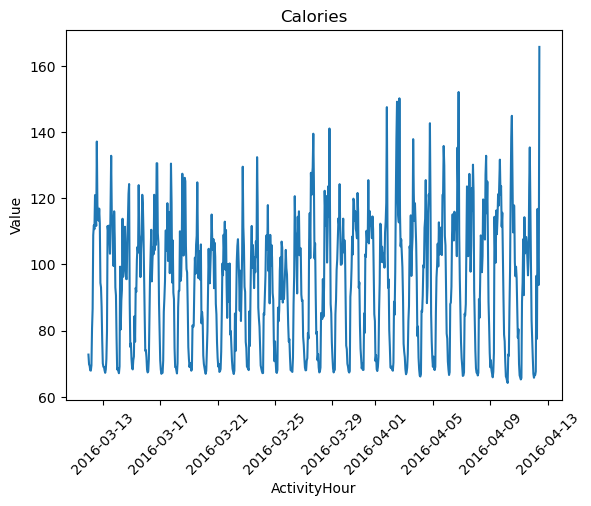

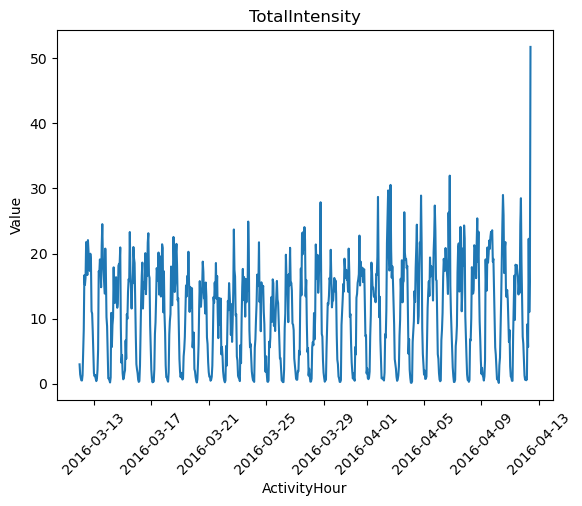

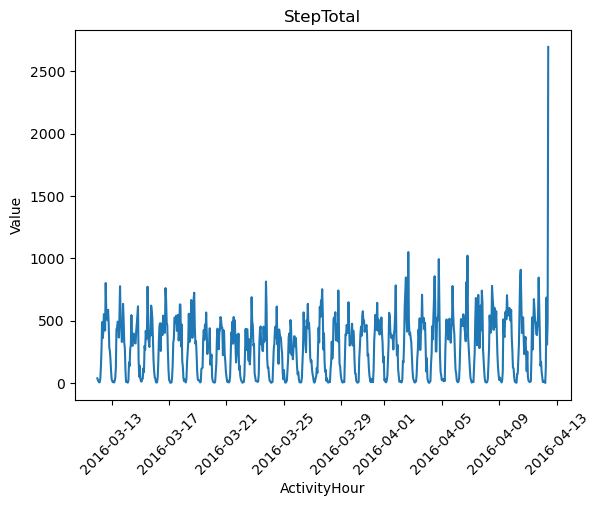

In [46]:
for var in means:
    ax = sns.lineplot(means[var])
    ax.set_title(f"{var}")
    ax.set_ylabel('Value')
    plt.xticks(rotation=45)
    plt.show()

## OLS

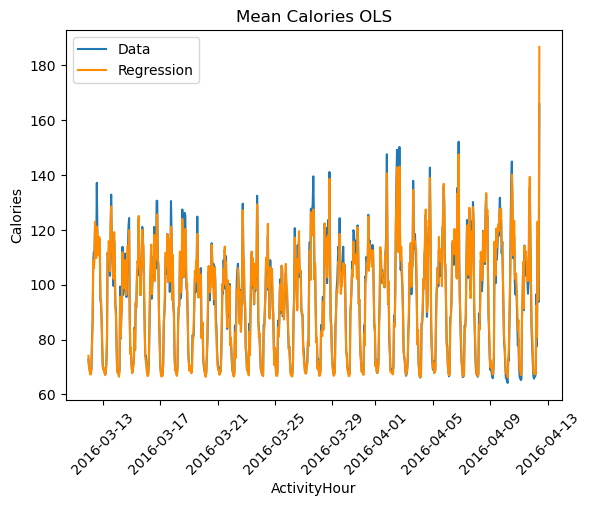

                            OLS Regression Results                            
Dep. Variable:               Calories   R-squared:                       0.979
Model:                            OLS   Adj. R-squared:                  0.979
Method:                 Least Squares   F-statistic:                 1.717e+04
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        11:50:52   Log-Likelihood:                -1869.6
No. Observations:                 755   AIC:                             3745.
Df Residuals:                     752   BIC:                             3759.
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             65.9116      0.195    338.

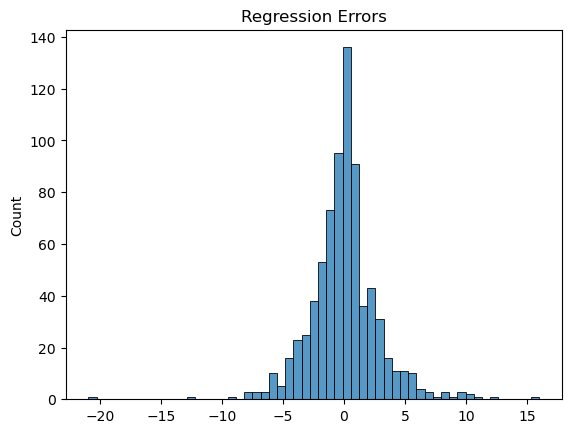

In [47]:
y = means['Calories']
X = means[['TotalIntensity', 'StepTotal']]
X = sm.add_constant(X)
plot_linear_regression(X, y, "Mean Calories OLS")

## STL

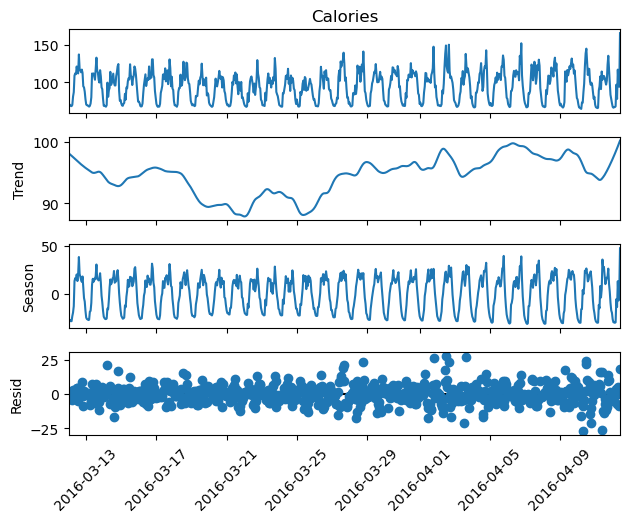

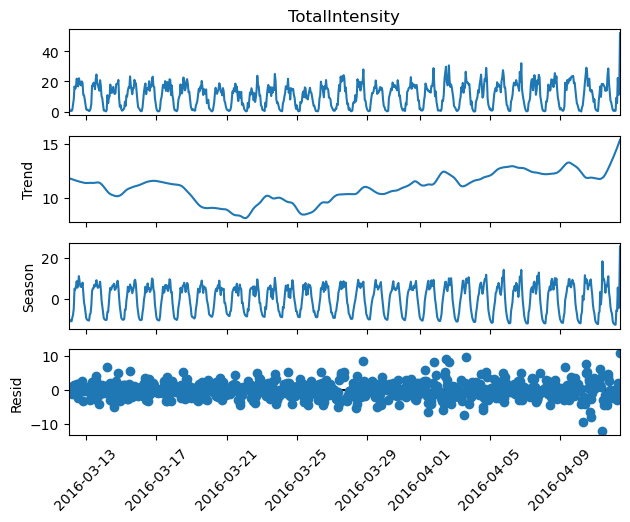

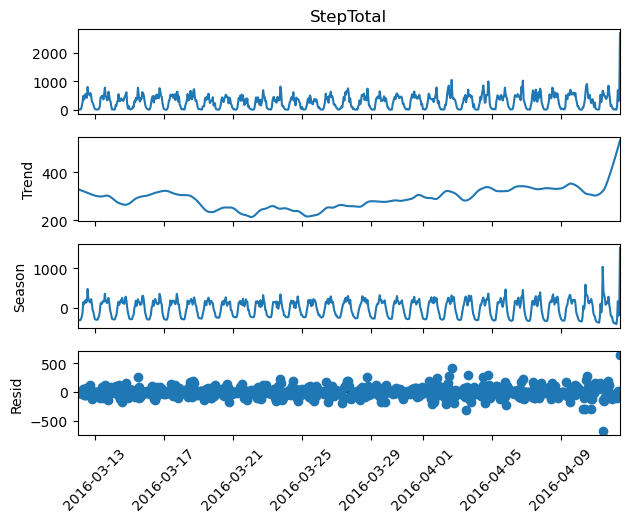

In [48]:
for var in means:
    stl = STL(means[var], period=24)
    res = stl.fit()
    fig = res.plot()
    plt.xticks(rotation=45)
    plt.show()

# Quantiles

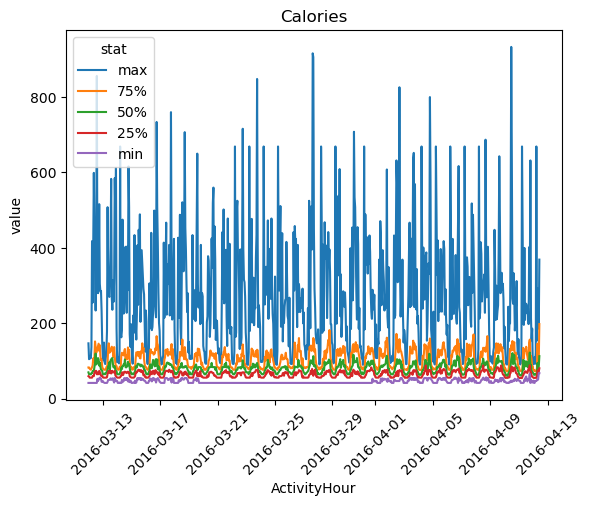

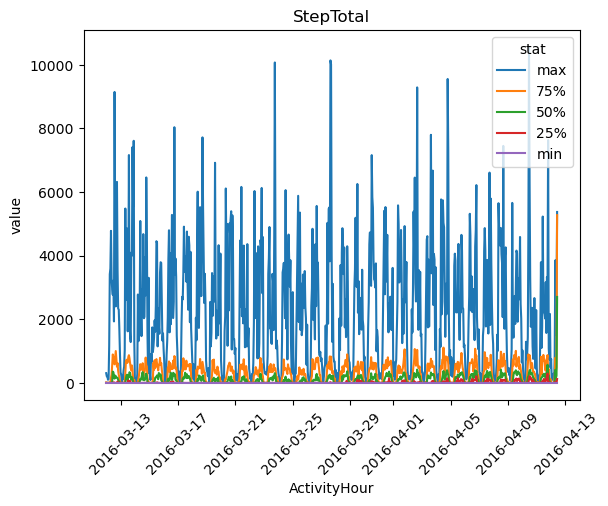

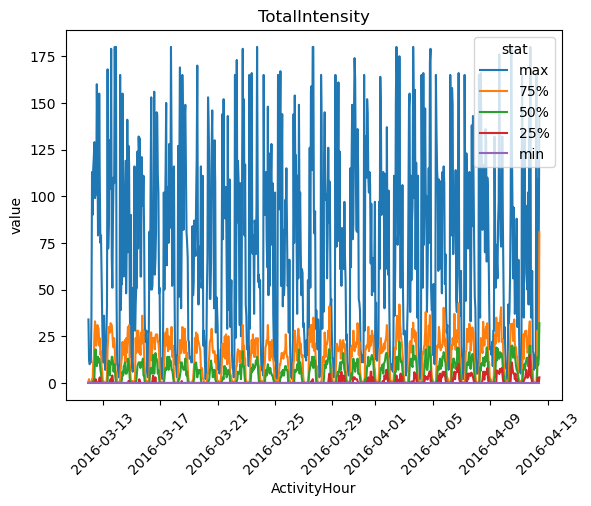

In [58]:
melt = df.melt(ignore_index=False)
stats = melt.groupby(['variable','ActivityHour'])['value'].describe().reset_index()
stats_melt = stats.melt(
                id_vars=['variable','ActivityHour'],
                value_vars=['min','25%','50%','75%','max'][::-1],
                var_name='stat',
                value_name='value'
)
for var in stats_melt['variable'].unique():
    var_df = stats_melt[stats_melt['variable'] == var]
    sns.lineplot(var_df, x='ActivityHour', y='value', hue='stat')
    plt.title(f"{var}")
    plt.xticks(rotation=45)
    plt.show()

# Heart Rates

In [68]:
hr_mean = pd.read_sql("""
                      SELECT Time,
                             AVG(value) AS mean
                      FROM heart_rate
                      GROUP BY Time
                      """, conn)
hr_mean['Time'] = pd.to_datetime(hr_mean['Time'], format=DATE_FMT)
hr_mean['date'] = hr_mean['Time'].dt.date
hr_mean['hour'] = hr_mean['Time'].dt.hour
hr_mean_stats = hr_mean.groupby(['date', 'hour'])['mean'].describe().drop(columns=['count','std'])
hr_mean_stats

mean   min    25%         50%    75%    max
date       hour                                                   
2016-03-29 0      69.252308  59.0   67.0   69.000000   70.0   89.0
           1      65.982456  59.0   63.0   65.000000   68.0   78.0
           2      67.343750  60.0   66.0   67.000000   69.0   77.0
           3      62.750000  56.0   61.0   62.000000   64.0   87.0
           4      60.514658  55.0   59.0   60.000000   62.0   71.0
...                     ...   ...    ...         ...    ...    ...
2016-04-12 7      77.982722  54.0   70.0   78.000000   85.0  128.0
           8      69.247652  47.0   57.0   66.416667   79.0  124.0
           9      92.383391  50.0   70.0   92.666667  114.0  134.0
           10    114.787439  60.0  104.0  118.000000  125.0  176.0
           11     71.520000  68.0   69.0   71.000000   74.0   76.0

[348 rows x 6 columns]

In [69]:
hourly_means = means.reset_index()
hourly_means['date'] = hourly_means['ActivityHour'].dt.date
hourly_means['hour'] = hourly_means['ActivityHour'].dt.hour
hourly_means = hourly_means.set_index(['date', 'hour'])
hourly_means = hr_mean_stats.add_prefix('hr_').join(hourly_means, how="inner").set_index('ActivityHour')
hourly_means

,hr_mean,hr_min,hr_25%,hr_50%,hr_75%,hr_max,Calories,TotalIntensity,StepTotal
ActivityHour,,,,,,,,,
2016-03-29 00:00:00,69.252308,59.0,67.0,69.000000,70.000000,89.0,72.030303,1.696970,33.272727
2016-03-29 01:00:00,65.982456,59.0,63.0,65.000000,68.000000,78.0,68.606061,0.909091,11.727273
2016-03-29 02:00:00,67.343750,60.0,66.0,67.000000,69.000000,77.0,67.363636,0.303030,3.363636
2016-03-29 03:00:00,62.750000,56.0,61.0,62.000000,64.000000,87.0,67.909091,0.484848,4.606061
2016-03-29 04:00:00,60.514658,55.0,59.0,60.000000,62.000000,71.0,68.181818,0.606061,11.666667
...,...,...,...,...,...,...,...,...,...
2016-04-12 06:00:00,74.248266,54.0,64.0,73.500000,80.541667,125.0,77.529412,5.647059,127.705882
2016-04-12 07:00:00,77.982722,54.0,70.0,78.000000,85.000000,128.0,116.800000,22.266667,684.533333
2016-04-12 08:00:00,69.247652,47.0,57.0,66.416667,79.000000,124.0,94.833333,11.000000,307.333333


In [70]:
hourly_means.corr()

,hr_mean,hr_min,hr_25%,hr_50%,hr_75%,hr_max,Calories,TotalIntensity,StepTotal
hr_mean,1.000000,0.512326,0.946450,0.979021,0.975951,0.786977,0.764476,0.766863,0.731485
hr_min,0.512326,1.000000,0.557460,0.485350,0.438312,0.313282,0.656409,0.628583,0.569382
hr_25%,0.946450,0.557460,1.000000,0.956673,0.868032,0.674268,0.754863,0.763862,0.722557
hr_50%,0.979021,0.485350,0.956673,1.000000,0.940265,0.712396,0.731097,0.741047,0.710258
hr_75%,0.975951,0.438312,0.868032,0.940265,1.000000,0.772422,0.712590,0.713360,0.687094
hr_max,0.786977,0.313282,0.674268,0.712396,0.772422,1.000000,0.635668,0.639972,0.617907
Calories,0.764476,0.656409,0.754863,0.731097,0.712590,0.635668,1.000000,0.986659,0.916495
TotalIntensity,0.766863,0.628583,0.763862,0.741047,0.713360,0.639972,0.986659,1.000000,0.949438
StepTotal,0.731485,0.569382,0.722557,0.710258,0.687094,0.617907,0.916495,0.949438,1.000000


## OLS

In [88]:
def plot_linear_regression(X, y, title="Title"):
    model = sm.OLS(y, X)
    results = model.fit()
    beta = results.params.values
    y_pred = X.dot(beta) if X.ndim >= 2 else beta * X
    
    sns.lineplot(y, label='Data')
    sns.lineplot(y_pred, label='Regression', color="darkorange")
    plt.title(title)
    plt.xticks(rotation=45)
    plt.legend()
    plt.show()

    print(results.summary())
    
    errors = y - y_pred
    ax1 = sns.histplot(errors)
    # ax2 = ax1.twinx()
    # sns.kdeplot(errors, ax=ax2)
    plt.title("Regression Errors")
    plt.show()

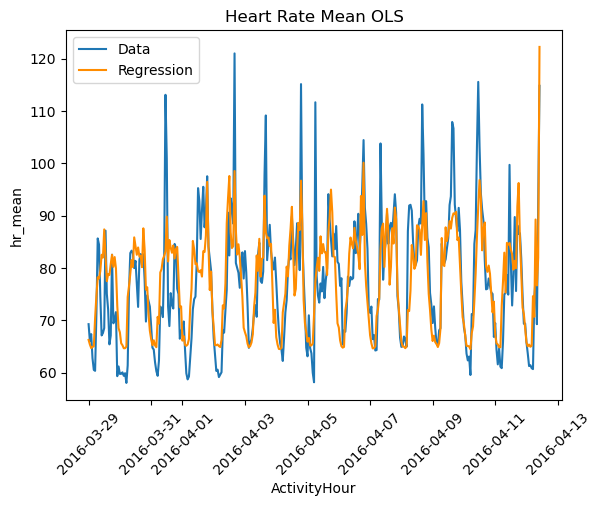

                            OLS Regression Results                            
Dep. Variable:                hr_mean   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.587
Method:                 Least Squares   F-statistic:                     492.5
Date:                Fri, 20 Mar 2026   Prob (F-statistic):           2.01e-68
Time:                        12:27:31   Log-Likelihood:                -1200.1
No. Observations:                 347   AIC:                             2404.
Df Residuals:                     345   BIC:                             2412.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const             64.3474      0.724     88.

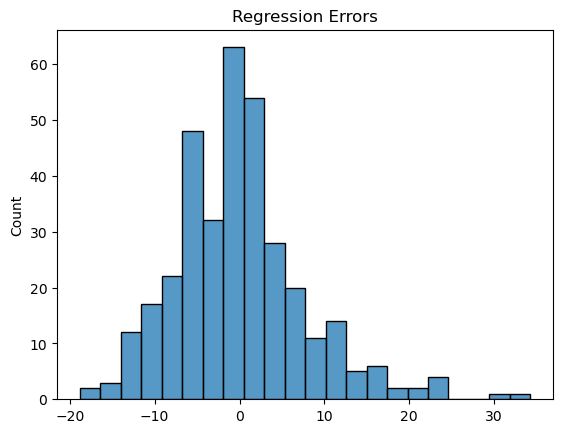

In [89]:
y = hourly_means['hr_mean']
X = hourly_means['TotalIntensity']
X = sm.add_constant(X)
plot_linear_regression(X, y, title="Heart Rate Mean OLS")

## STL

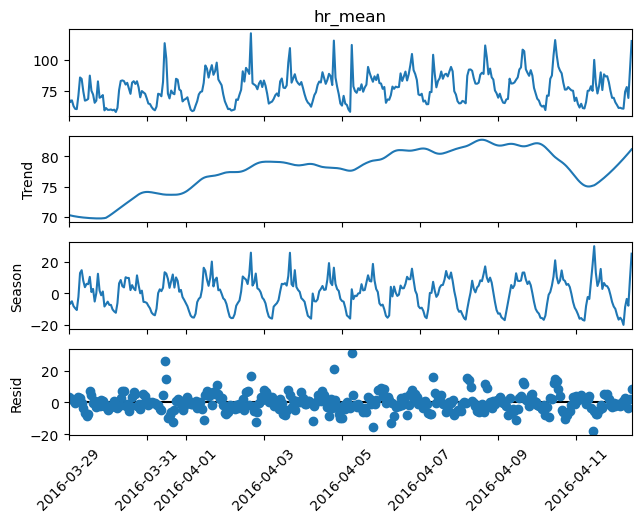

In [85]:
stl = STL(hourly_means['hr_mean'], period=24)
res = stl.fit()
fig = res.plot()
plt.xticks(rotation=45)
plt.show()